# OCR Pipeline for Arabic Legal Documents

This notebook implements a complete OCR pipeline optimized for **printed** Arabic legal case documents.

## Pipeline Layers
1. **Document Ingestion** - Load PDF/image files
2. **Image Restoration** - Denoise, contrast, illumination normalization
3. **Deskewing** - Detect and correct document tilt/rotation
4. **Page Isolation** - Detect page boundaries, mask out-of-page noise
5. **Layout Analysis** - Detect text regions, classify printed vs handwritten
6. **OCR Engine** - Region-aware Tesseract OCR with tuned configs
7. **Text Reconstruction** - Clean, normalize, and merge OCR output
8. **LLM Refinement** - Use an LLM to correct OCR errors in the final text

In [1]:
# Standard Library
import os
import math
import re
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from dotenv import load_dotenv

load_dotenv()

# Third Party
import numpy as np
import cv2
from PIL import Image
from pdf2image import convert_from_path
import pytesseract
import matplotlib.pyplot as plt
import google.generativeai as genai
from google.generativeai import types as genai_types

e:\Anaconda3\envs\ai-judge\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\seife\AppData\Local\Temp\ipykernel_23928\4182995940.py:20: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Layer 1: Document Ingestion

In [2]:
# ===============================
# Dataclasses
# ===============================

@dataclass
class PageImage:
    image: np.ndarray
    page_number: int
    width: int
    height: int
    dpi: int


@dataclass
class Document:
    pages: List[PageImage]
    source_type: str  # "pdf" or "image"
    dpi: int
    total_pages: int

In [3]:
# ===============================
# Helper Functions
# ===============================

SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}
SUPPORTED_PDF_EXTENSIONS = {".pdf"}
CURRENT_DIR = Path(os.getcwd()) 
BASE_DIR = CURRENT_DIR.parent.parent


def _validate_file(path: Path):
    print(f"[INFO] Validating file: {path}")
    if not path.exists():
        raise FileNotFoundError(f"[ERROR] File does not exist: {path}")
    if not path.is_file():
        raise ValueError(f"[ERROR] Path is not a file: {path}")


def _get_file_type(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix in SUPPORTED_PDF_EXTENSIONS:
        return "pdf"
    elif suffix in SUPPORTED_IMAGE_EXTENSIONS:
        return "image"
    else:
        raise ValueError(f"[ERROR] Unsupported file type: {suffix}")


def _pil_to_numpy_rgb(pil_image: Image.Image) -> np.ndarray:
    """Convert PIL image to RGB NumPy array safely."""
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")
    return np.array(pil_image)


def _load_image_file(path: Path, default_dpi: int = 300) -> PageImage:
    """Load a single image file safely and normalize to RGB."""
    print(f"[INFO] Loading image file: {path.name}")
    try:
        pil_img = Image.open(path)
        pil_img.verify()
        pil_img = Image.open(path)  # Re-open after verify
    except Exception as e:
        raise ValueError(f"[ERROR] Corrupted or unreadable image file: {e}")

    np_img = _pil_to_numpy_rgb(pil_img)
    height, width = np_img.shape[:2]

    return PageImage(
        image=np_img,
        page_number=1,
        width=width,
        height=height,
        dpi=default_dpi
    )


def _convert_pdf_to_pages(path: Path, dpi: int = 400) -> List[PageImage]:
    """Convert PDF pages to high-DPI RGB images."""
    print(f"[INFO] Converting PDF to images at {dpi} DPI: {path.name}")
    try:
        pil_pages = convert_from_path(str(path), dpi=dpi)
    except Exception as e:
        raise RuntimeError(f"[ERROR] Failed to convert PDF: {e}")

    pages = []
    for idx, pil_page in enumerate(pil_pages):
        np_img = _pil_to_numpy_rgb(pil_page)
        height, width = np_img.shape[:2]
        pages.append(
            PageImage(
                image=np_img,
                page_number=idx + 1,
                width=width,
                height=height,
                dpi=dpi
            )
        )

    print(f"[INFO] PDF converted successfully. Total pages: {len(pages)}")
    return pages

In [4]:
# ===============================
# Main Ingestion Function
# ===============================

def ingest_document(file_path: str, pdf_dpi: int = 400) -> Document:
    """
    Ingest a PDF or image file and return a structured Document object.
    """
    path = Path(file_path)
    final_path = BASE_DIR / path

    print(f"[INFO] Starting ingestion: {final_path.name}")
    _validate_file(final_path)
    file_type = _get_file_type(final_path)

    if file_type == "pdf":
        pages = _convert_pdf_to_pages(final_path, dpi=pdf_dpi)
        source_dpi = pdf_dpi
    elif file_type == "image":
        page = _load_image_file(final_path)
        pages = [page]
        source_dpi = page.dpi
    else:
        raise RuntimeError("[ERROR] Unexpected file type encountered.")

    document = Document(
        pages=pages,
        source_type=file_type,
        dpi=source_dpi,
        total_pages=len(pages)
    )

    print(f"[SUCCESS] Ingestion complete.")
    print(f"          Source type : {document.source_type}")
    print(f"          Total pages : {document.total_pages}")
    print(f"          DPI         : {document.dpi}")

    return document

In [5]:
# ===============================
# Example Usage - Update path as needed
# ===============================

file_path = "Case Sample\\Case_Sample(4).jpeg"

try:
    document = ingest_document(file_path)
    first_page = document.pages[0]

    print("\n--- First Page Info ---")
    print("Page number:", first_page.page_number)
    print("Width:", first_page.width)
    print("Height:", first_page.height)
    print("DPI:", first_page.dpi)
except Exception as e:
    print(str(e))

[INFO] Starting ingestion: Case_Sample(4).jpeg
[INFO] Validating file: e:\Anaconda3\envs\Judge-Assistant\Case Sample\Case_Sample(4).jpeg
[INFO] Loading image file: Case_Sample(4).jpeg
[SUCCESS] Ingestion complete.
          Source type : image
          Total pages : 1
          DPI         : 300

--- First Page Info ---
Page number: 1
Width: 829
Height: 1026
DPI: 300


## Layer 2: Image Restoration

In [6]:
# ==========================================
# Quality Metric Utilities
# ==========================================

def compute_mean_intensity(image_rgb: np.ndarray) -> float:
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return float(np.mean(gray))


def compute_contrast_estimate(image_rgb: np.ndarray) -> float:
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return float(np.std(gray))


def compute_noise_estimate(image_rgb: np.ndarray) -> float:
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return float(lap.var())

In [7]:
# ==========================================
# Image Restoration Pipeline
# ==========================================

class ImageRestorationPipeline:

    def __init__(
        self,
        denoise_strength: int = 10,
        clahe_clip_limit: float = 2.0,
        clahe_tile_grid_size: Tuple[int, int] = (8, 8),
        morph_kernel_size: int = 2,
        illumination_blur_kernel: int = 51
    ):
        self.denoise_strength = denoise_strength
        self.clahe_clip_limit = clahe_clip_limit
        self.clahe_tile_grid_size = clahe_tile_grid_size
        self.morph_kernel_size = morph_kernel_size
        self.illumination_blur_kernel = illumination_blur_kernel

    def _denoise(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   -> Applying denoising...")
        denoised = cv2.fastNlMeansDenoisingColored(
            image_rgb, None,
            self.denoise_strength, self.denoise_strength, 7, 21
        )
        return denoised

    def _enhance_contrast(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   -> Enhancing contrast (CLAHE)...")
        lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(
            clipLimit=self.clahe_clip_limit,
            tileGridSize=self.clahe_tile_grid_size
        )
        l_enhanced = clahe.apply(l)
        merged = cv2.merge((l_enhanced, a, b))
        enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
        return enhanced_rgb

    def _normalize_background(self, image_rgb: np.ndarray) -> np.ndarray:
        print("   -> Normalizing background illumination...")
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        blur = cv2.GaussianBlur(
            gray,
            (self.illumination_blur_kernel, self.illumination_blur_kernel), 0
        )
        blur = blur.astype(np.float32) + 1e-5
        normalized = gray.astype(np.float32) / blur
        normalized = cv2.normalize(normalized, None, 0, 255, cv2.NORM_MINMAX)
        normalized = normalized.astype(np.uint8)
        normalized_rgb = cv2.cvtColor(normalized, cv2.COLOR_GRAY2RGB)
        return normalized_rgb

    def process_page(self, image_rgb: np.ndarray) -> np.ndarray:
        """
        Restoration pipeline for a single page.
        NOTE: We removed _repair_strokes because morphological closing
        was destroying Arabic diacritics on printed text. For printed
        documents the denoise + contrast + background normalization
        is sufficient.
        """
        step1 = self._denoise(image_rgb)
        step2 = self._enhance_contrast(step1)
        step3 = self._normalize_background(step2)
        return step3

In [8]:
# ==========================================
# Restore Entire Document
# ==========================================

def restore_document(document):
    print("\n[INFO] Starting restoration pipeline...\n")
    pipeline = ImageRestorationPipeline()
    restored_pages = []

    for page in document.pages:
        print(f"[PAGE {page.page_number}]")
        original_image = page.image

        mean_before = compute_mean_intensity(original_image)
        contrast_before = compute_contrast_estimate(original_image)
        noise_before = compute_noise_estimate(original_image)
        print(f"   Before -> Mean: {mean_before:.2f} | Contrast: {contrast_before:.2f} | Noise: {noise_before:.2f}")

        restored_image = pipeline.process_page(original_image)

        mean_after = compute_mean_intensity(restored_image)
        contrast_after = compute_contrast_estimate(restored_image)
        noise_after = compute_noise_estimate(restored_image)
        print(f"   After  -> Mean: {mean_after:.2f} | Contrast: {contrast_after:.2f} | Noise: {noise_after:.2f}\n")

        restored_pages.append(
            PageImage(
                image=restored_image,
                page_number=page.page_number,
                width=page.width,
                height=page.height,
                dpi=page.dpi
            )
        )

    restored_document = Document(
        pages=restored_pages,
        source_type=document.source_type,
        dpi=document.dpi,
        total_pages=document.total_pages
    )

    print("[SUCCESS] Document restoration complete.\n")
    return restored_document

In [9]:
restored_document = restore_document(document)
restored_page_1 = restored_document.pages[0]


[INFO] Starting restoration pipeline...

[PAGE 1]
   Before -> Mean: 186.42 | Contrast: 25.43 | Noise: 983.46
   -> Applying denoising...
   -> Enhancing contrast (CLAHE)...
   -> Normalizing background illumination...
   After  -> Mean: 145.65 | Contrast: 20.54 | Noise: 796.13

[SUCCESS] Document restoration complete.



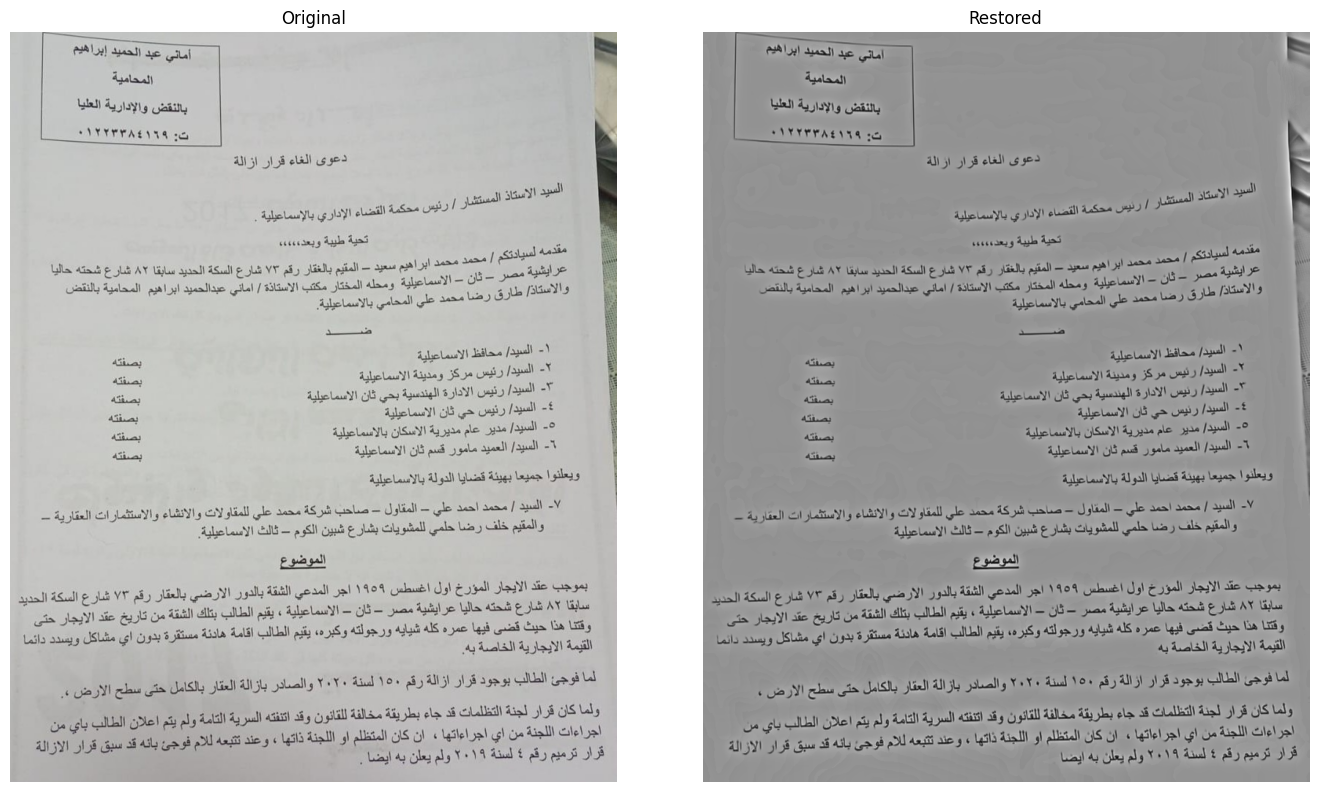

In [10]:
def show_before_after(original_page, restored_page, figsize=(14, 8)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(original_page.image)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(restored_page.image)
    axes[1].set_title("Restored")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

show_before_after(document.pages[0], restored_page_1)

## Layer 3: Deskewing

Since the documents are photographed paper, the page may be rotated or the text lines may be slightly tilted in either direction. This layer detects the skew angle and rotates the image to correct it before page isolation and OCR.

**Approach:**
1. Convert to grayscale and binarize with Otsu threshold
2. Use two complementary methods to estimate the skew angle:
   - **Hough Line Transform** - detects dominant line angles in the image
   - **Minimum Area Rectangle** - fits a rotated rectangle around text pixels
3. Average the two estimates (weighted by confidence) for a robust angle
4. Rotate the image by the negative of the detected angle to deskew
5. Fill any exposed borders with white (background color)

The deskewing is applied after image restoration but before page isolation, so that the page boundary detection works on a properly oriented image.

In [11]:
# ==========================================
# Deskewing - Detect and correct document tilt
# ==========================================

class DocumentDeskewer:
    """
    Detects and corrects skew (tilt/rotation) in scanned or photographed
    document pages. Uses a combination of Hough Line Transform and
    minimum-area-rectangle fitting for robust angle estimation.
    """

    def __init__(
        self,
        max_skew_angle: float = 15.0,
        hough_threshold: int = 200,
        min_line_length: int = 100,
        angle_tolerance: float = 0.1
    ):
        """
        Args:
            max_skew_angle: Maximum expected skew in degrees. Angles beyond
                            this are likely detection errors and are ignored.
            hough_threshold: Accumulator threshold for HoughLinesP.
            min_line_length: Minimum line length (pixels) for Hough detection.
            angle_tolerance: If the detected angle is below this (degrees),
                             skip rotation (image is already straight).
        """
        self.max_skew_angle = max_skew_angle
        self.hough_threshold = hough_threshold
        self.min_line_length = min_line_length
        self.angle_tolerance = angle_tolerance

    def _estimate_angle_hough(self, gray: np.ndarray) -> Optional[float]:
        """
        Estimate skew angle using the Hough Line Transform.
        Detects near-horizontal lines (text baselines) and computes
        the median angle deviation from horizontal.
        """
        edges = cv2.Canny(gray, 50, 150, apertureSize=3)

        # Dilate edges slightly to connect broken text baselines
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 1))
        edges = cv2.dilate(edges, kernel, iterations=1)

        lines = cv2.HoughLinesP(
            edges,
            rho=1,
            theta=np.pi / 180,
            threshold=self.hough_threshold,
            minLineLength=self.min_line_length,
            maxLineGap=20
        )

        if lines is None or len(lines) == 0:
            return None

        angles = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            dx = x2 - x1
            dy = y2 - y1
            if abs(dx) < 1:  # Skip near-vertical lines
                continue
            angle = math.degrees(math.atan2(dy, dx))
            # Only consider near-horizontal lines (within max_skew range)
            if abs(angle) <= self.max_skew_angle:
                angles.append(angle)

        if not angles:
            return None

        # Use median to be robust against outlier lines
        return float(np.median(angles))

    def _estimate_angle_minarea(self, gray: np.ndarray) -> Optional[float]:
        """
        Estimate skew angle using minimum-area rectangle fitting.
        Binarizes the image, finds all text pixels, and fits a
        rotated rectangle around them.
        """
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Find coordinates of all foreground (text) pixels
        coords = np.column_stack(np.where(binary > 0))

        if len(coords) < 100:  # Not enough text pixels
            return None

        # cv2.minAreaRect expects (x, y) format, coords are (row, col)
        rect = cv2.minAreaRect(coords[:, ::-1])  # Swap to (x, y)
        angle = rect[-1]  # Angle from minAreaRect

        # minAreaRect returns angles in [-90, 0)
        # Normalize: if angle < -45, the rectangle is closer to vertical
        if angle < -45:
            angle = angle + 90

        if abs(angle) > self.max_skew_angle:
            return None

        return float(angle)

    def detect_skew_angle(self, image_rgb: np.ndarray) -> float:
        """
        Detect the skew angle of the document image.

        Uses both Hough lines and min-area-rect, then combines them.
        Returns the estimated angle in degrees (positive = clockwise tilt).
        """
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        angle_hough = self._estimate_angle_hough(gray)
        angle_rect = self._estimate_angle_minarea(gray)

        print(f"   -> Hough angle: {angle_hough:.3f} deg" if angle_hough is not None else "   -> Hough angle: N/A")
        print(f"   -> MinAreaRect angle: {angle_rect:.3f} deg" if angle_rect is not None else "   -> MinAreaRect angle: N/A")

        # Combine estimates
        if angle_hough is not None and angle_rect is not None:
            # If both agree (within 2 degrees), average them
            if abs(angle_hough - angle_rect) < 2.0:
                angle = (angle_hough + angle_rect) / 2.0
            else:
                # Prefer Hough (more reliable for text baselines)
                angle = angle_hough
        elif angle_hough is not None:
            angle = angle_hough
        elif angle_rect is not None:
            angle = angle_rect
        else:
            angle = 0.0

        return angle

    def deskew_image(self, image_rgb: np.ndarray) -> Tuple[np.ndarray, float]:
        """
        Detect skew and rotate the image to correct it.

        Returns:
            - Deskewed image (RGB)
            - The angle that was corrected (degrees)
        """
        angle = self.detect_skew_angle(image_rgb)

        if abs(angle) < self.angle_tolerance:
            print(f"   -> Skew angle {angle:.3f} deg is below tolerance ({self.angle_tolerance}), skipping rotation")
            return image_rgb.copy(), 0.0

        print(f"   -> Correcting skew: {angle:.3f} degrees")

        h, w = image_rgb.shape[:2]
        center = (w // 2, h // 2)

        # Rotation matrix (negative angle to correct the tilt)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        # Compute new bounding dimensions to avoid cropping corners
        cos_a = abs(M[0, 0])
        sin_a = abs(M[0, 1])
        new_w = int(h * sin_a + w * cos_a)
        new_h = int(h * cos_a + w * sin_a)

        # Adjust the rotation matrix for the new canvas size
        M[0, 2] += (new_w - w) / 2
        M[1, 2] += (new_h - h) / 2

        # Rotate with white border fill
        rotated = cv2.warpAffine(
            image_rgb, M, (new_w, new_h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(255, 255, 255)
        )

        return rotated, angle


def deskew_document(document: Document) -> Document:
    """
    Run deskewing on every page of the document.
    Returns a new Document with deskewed pages.
    """
    print("\n[INFO] Starting deskewing pipeline...\n")
    deskewer = DocumentDeskewer()
    deskewed_pages = []

    for page in document.pages:
        print(f"[PAGE {page.page_number}]")
        deskewed_img, angle = deskewer.deskew_image(page.image)
        new_h, new_w = deskewed_img.shape[:2]
        print(f"   -> Corrected angle: {angle:.3f} deg | New size: {new_w}x{new_h}\n")

        deskewed_pages.append(
            PageImage(
                image=deskewed_img,
                page_number=page.page_number,
                width=new_w,
                height=new_h,
                dpi=page.dpi
            )
        )

    print("[SUCCESS] Deskewing complete.\n")
    return Document(
        pages=deskewed_pages,
        source_type=document.source_type,
        dpi=document.dpi,
        total_pages=document.total_pages
    )


[INFO] Starting deskewing pipeline...

[PAGE 1]
   -> Hough angle: -1.035 deg
   -> MinAreaRect angle: 0.457 deg
   -> Correcting skew: -0.289 degrees
   -> Corrected angle: -0.289 deg | New size: 834x1030

[SUCCESS] Deskewing complete.



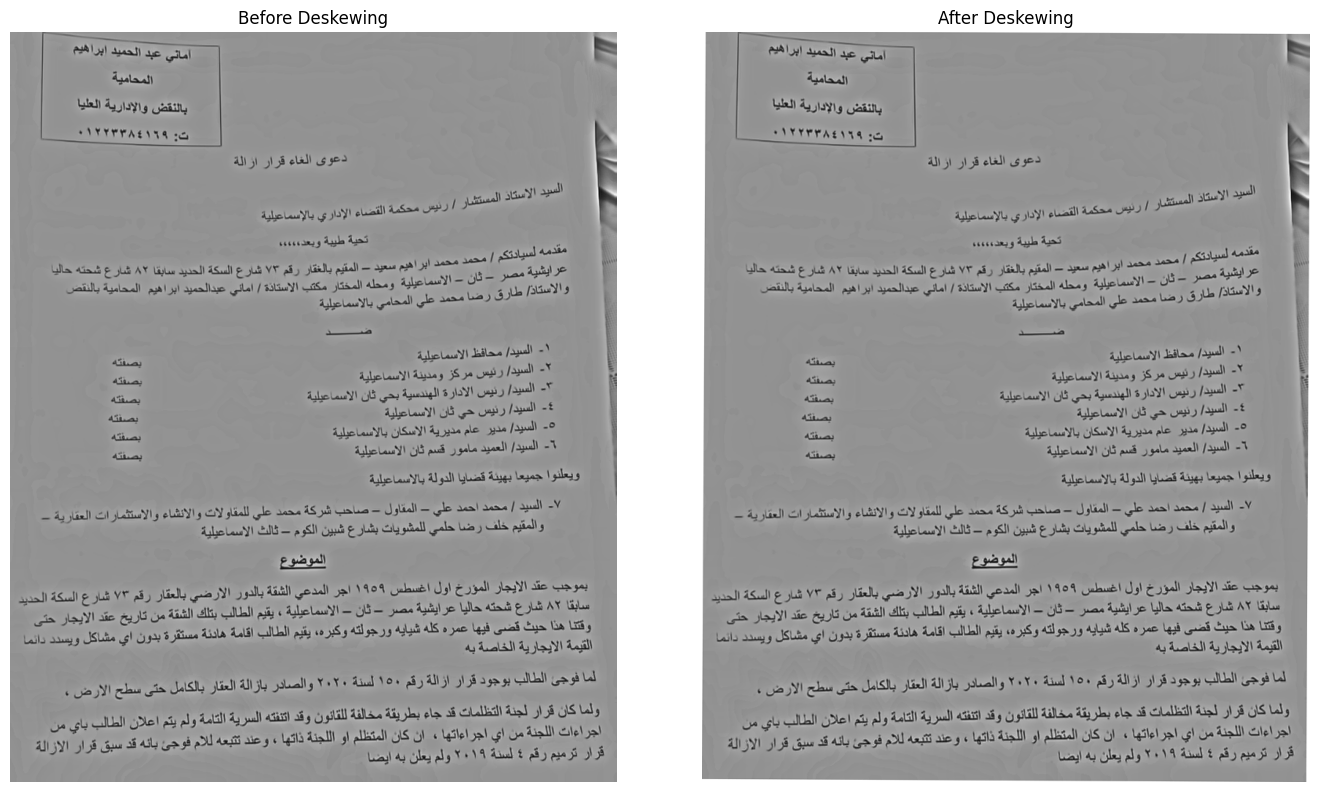

In [12]:
deskewed_document = deskew_document(restored_document)

# Visualize before/after deskewing
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(restored_document.pages[0].image)
axes[0].set_title("Before Deskewing")
axes[0].axis("off")
axes[1].imshow(deskewed_document.pages[0].image)
axes[1].set_title("After Deskewing")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Layer 4: Page Isolation

**FIX**: The old approach used a simple Otsu threshold + largest contour to detect the page, but it was not reliable. Content outside the physical page (e.g. dark scanner borders, table edges, background noise) was leaking into the OCR regions.

The new approach:
1. Uses adaptive thresholding + morphological operations to find the page rectangle
2. Applies a convex hull or approxPolyDP to find the page quadrilateral
3. Creates a mask that zeros out everything outside the page boundary
4. Crops to the page bounding box with a small margin

In [13]:
# ==========================================
# Page Isolation - Detect and crop to page boundary
# ==========================================

class PageIsolator:
    """
    Detects the physical page boundary in a scanned image and
    masks/crops everything outside it. This prevents the OCR from
    picking up scanner artifacts, dark borders, or adjacent pages.
    """

    def __init__(self, margin_pct: float = 0.02, min_page_area_ratio: float = 0.3):
        """
        Args:
            margin_pct: percentage of image dimension to use as inner margin
                        when cropping (avoids cutting into page edges)
            min_page_area_ratio: minimum ratio of contour area to image area
                                 for a contour to be considered the page
        """
        self.margin_pct = margin_pct
        self.min_page_area_ratio = min_page_area_ratio

    def _find_page_contour(self, image_rgb: np.ndarray):
        """
        Find the largest rectangular-ish contour that represents the page.
        Returns the contour and its bounding rect, or None if not found.
        """
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        h, w = gray.shape[:2]
        img_area = h * w

        # Use Gaussian blur to reduce noise before edge detection
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)

        # Canny edge detection
        edges = cv2.Canny(blurred, 30, 100)

        # Dilate edges to connect nearby edge segments
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        dilated = cv2.dilate(edges, kernel, iterations=2)

        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None

        # Sort by area, largest first
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        for cnt in contours:
            area = cv2.contourArea(cnt)

            # Must be at least min_page_area_ratio of the image
            if area < img_area * self.min_page_area_ratio:
                continue

            # Try to approximate to a quadrilateral
            peri = cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

            # Accept 4-sided or use bounding rect for irregular shapes
            if len(approx) >= 4:
                return cnt

        # Fallback: use the largest contour if it is big enough
        largest = contours[0]
        if cv2.contourArea(largest) >= img_area * self.min_page_area_ratio:
            return largest

        return None

    def isolate_page(self, image_rgb: np.ndarray) -> Tuple[np.ndarray, Tuple[int, int, int, int]]:
        """
        Isolate the page from the background.

        Returns:
            - Cropped image containing only the page content (with white
              background replacing out-of-page areas)
            - Bounding box (x, y, w, h) of the page in the original image
        """
        h, w = image_rgb.shape[:2]
        page_cnt = self._find_page_contour(image_rgb)

        if page_cnt is None:
            print("   [WARN] Could not detect page boundary, using full image")
            return image_rgb.copy(), (0, 0, w, h)

        # Create a mask from the page contour
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.drawContours(mask, [page_cnt], -1, 255, thickness=cv2.FILLED)

        # Apply mask: set everything outside the page to white
        result = image_rgb.copy()
        result[mask == 0] = [255, 255, 255]

        # Get bounding rect with margin
        x, y, bw, bh = cv2.boundingRect(page_cnt)
        margin_x = int(w * self.margin_pct)
        margin_y = int(h * self.margin_pct)

        x1 = max(0, x - margin_x)
        y1 = max(0, y - margin_y)
        x2 = min(w, x + bw + margin_x)
        y2 = min(h, y + bh + margin_y)

        cropped = result[y1:y2, x1:x2]
        print(f"   -> Page isolated: ({x1},{y1}) to ({x2},{y2}) from {w}x{h}")

        return cropped, (x1, y1, x2 - x1, y2 - y1)


def isolate_document_pages(document: Document) -> Document:
    """
    Run page isolation on every page of the document.
    Returns a new Document with cropped/masked pages.
    """
    print("\n[INFO] Isolating page boundaries...\n")
    isolator = PageIsolator()
    isolated_pages = []

    for page in document.pages:
        print(f"[PAGE {page.page_number}]")
        isolated_img, bbox = isolator.isolate_page(page.image)
        new_h, new_w = isolated_img.shape[:2]

        isolated_pages.append(
            PageImage(
                image=isolated_img,
                page_number=page.page_number,
                width=new_w,
                height=new_h,
                dpi=page.dpi
            )
        )

    print("\n[SUCCESS] Page isolation complete.\n")
    return Document(
        pages=isolated_pages,
        source_type=document.source_type,
        dpi=document.dpi,
        total_pages=document.total_pages
    )


[INFO] Isolating page boundaries...

[PAGE 1]
   [WARN] Could not detect page boundary, using full image

[SUCCESS] Page isolation complete.



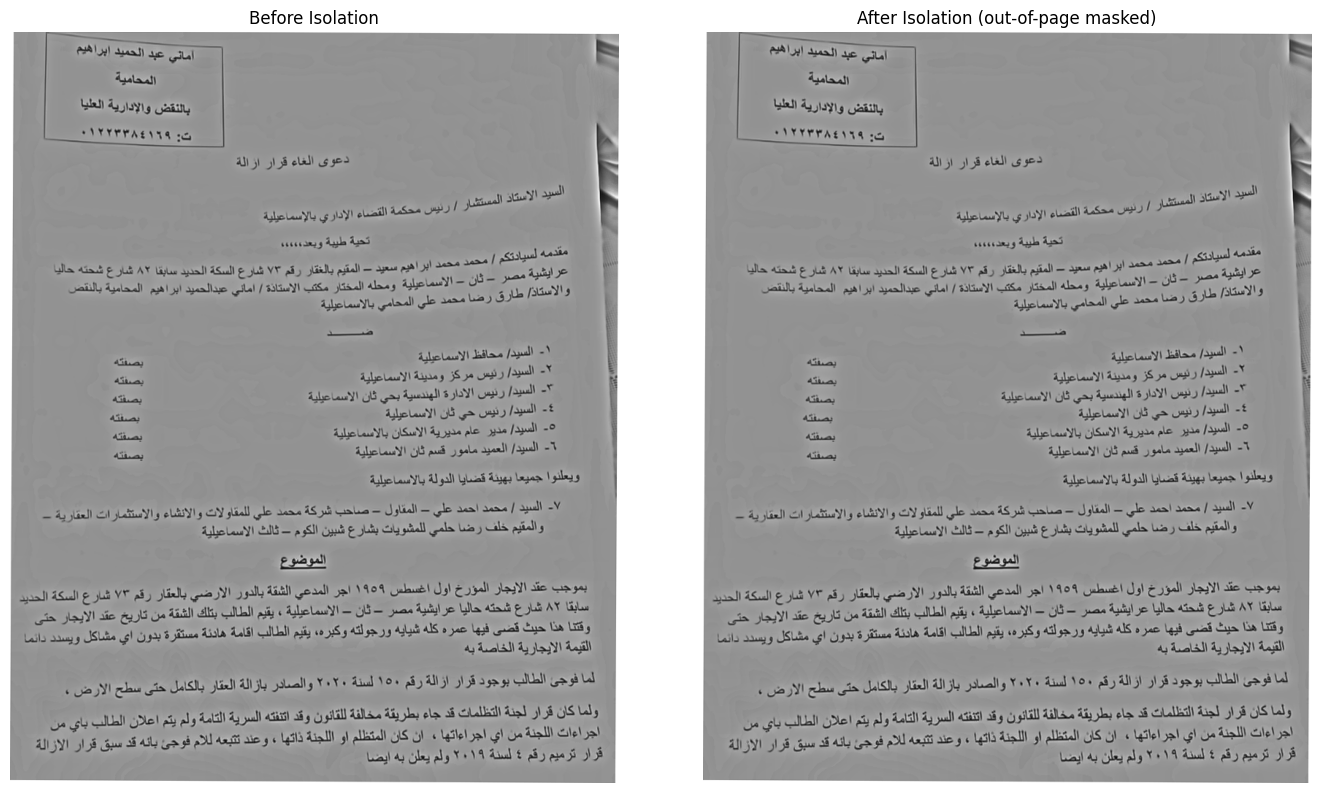

In [14]:
isolated_document = isolate_document_pages(deskewed_document)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(deskewed_document.pages[0].image)
axes[0].set_title("Before Isolation")
axes[0].axis("off")
axes[1].imshow(isolated_document.pages[0].image)
axes[1].set_title("After Isolation (out-of-page masked)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Layer 5: Layout Analysis

**FIX**: The old classifier labeled almost everything as "handwritten" because:
1. The entropy threshold (4.5) was too low -- printed Arabic text routinely has entropy > 4.5
2. The stroke_var threshold (3.0) was too low -- printed Arabic ligatures produce moderate stroke variation
3. The cc_irregularity threshold (1.0) was too low for Arabic script

The new approach:
- Raised thresholds significantly based on Arabic text characteristics
- Added a **line regularity** feature: printed text has very uniform line spacing
- Changed the scoring to require stronger evidence before labeling as handwritten
- Default assumption is **printed** (since we know the use case is printed legal docs)

In [15]:
# ==========================================
# Structured Output Dataclasses
# ==========================================

@dataclass
class Region:
    bbox: Tuple[int, int, int, int]  # (x, y, w, h)
    region_type: str                 # "printed" or "handwritten"
    confidence: float
    cropped_image: np.ndarray


@dataclass
class StructuredPage:
    page_number: int
    regions: List[Region]


@dataclass
class StructuredDocument:
    pages: List[StructuredPage]

In [16]:
# ==========================================
# Feature Extraction Utilities
# ==========================================

def compute_entropy(gray: np.ndarray) -> float:
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return float(-np.sum(hist * np.log2(hist)))


def stroke_width_variation(gray: np.ndarray) -> float:
    edges = cv2.Canny(gray, 50, 150)
    dist = cv2.distanceTransform(255 - edges, cv2.DIST_L2, 3)
    return float(np.std(dist))


def edge_density(gray: np.ndarray) -> float:
    edges = cv2.Canny(gray, 50, 150)
    return float(np.sum(edges > 0) / edges.size)


def connected_component_irregularity(gray: np.ndarray) -> float:
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh)

    if num_labels <= 1:
        return 0.0

    areas = stats[1:, cv2.CC_STAT_AREA]
    return float(np.std(areas) / (np.mean(areas) + 1e-5))


def line_spacing_regularity(gray: np.ndarray) -> float:
    """
    Measure how regular the horizontal line spacing is.
    Printed text has very uniform line gaps; handwritten does not.

    Returns a value between 0 and 1.
    Higher = more regular = more likely printed.
    """
    # Project horizontally to get row density
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    row_sums = np.sum(binary, axis=1)

    # Find text rows (where row_sum > threshold)
    threshold = np.max(row_sums) * 0.1
    is_text_row = row_sums > threshold

    # Find gaps between text lines
    gaps = []
    in_gap = False
    gap_start = 0
    for i in range(len(is_text_row)):
        if not is_text_row[i] and not in_gap:
            in_gap = True
            gap_start = i
        elif is_text_row[i] and in_gap:
            in_gap = False
            gap_len = i - gap_start
            if gap_len > 3:  # Ignore tiny gaps
                gaps.append(gap_len)

    if len(gaps) < 2:
        return 0.5  # Not enough data

    # Coefficient of variation of gap sizes
    gaps = np.array(gaps)
    cv_val = np.std(gaps) / (np.mean(gaps) + 1e-5)

    # Lower CV = more regular spacing = more likely printed
    # Map to 0-1 where 1 = very regular
    regularity = max(0.0, 1.0 - cv_val)
    return float(regularity)

In [17]:
# ==========================================
# Layout Analyzer (IMPROVED)
# ==========================================

class LayoutAnalyzer:

    def __init__(self, min_region_area: int = 2000):
        self.min_region_area = min_region_area

    def _detect_text_regions(self, image_rgb: np.ndarray):
        """
        Detect text regions within the (already isolated) page image.

        Since the page has already been isolated in Layer 3, we don't
        need complex page-boundary detection here. We just detect
        text blocks using adaptive thresholding + morphological grouping.
        """
        print("   -> Detecting text regions...")
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        h, w = gray.shape[:2]

        # Adaptive threshold to find text pixels
        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            31, 10
        )

        # Remove tiny noise specks
        noise_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, noise_kernel)

        # Morphological grouping - group text into line-level blocks
        # Horizontal emphasis to merge words within a line
        group_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 8))
        grouped = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, group_kernel)

        contours, _ = cv2.findContours(
            grouped, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        regions = []
        # Define a safe zone: ignore regions too close to image edges
        edge_margin = int(min(w, h) * 0.02)

        for cnt in contours:
            x, y, rw, rh = cv2.boundingRect(cnt)
            area = rw * rh

            if area < self.min_region_area:
                continue

            # Skip regions that are mostly at the image edge
            if x < edge_margin and rw < edge_margin * 3:
                continue
            if y < edge_margin and rh < edge_margin * 3:
                continue
            if (x + rw) > (w - edge_margin) and rw < edge_margin * 3:
                continue
            if (y + rh) > (h - edge_margin) and rh < edge_margin * 3:
                continue

            # Skip regions with extreme aspect ratios (likely noise)
            aspect = rw / (rh + 1e-5)
            if aspect > 50 or aspect < 0.02:
                continue

            regions.append((x, y, rw, rh))

        return regions

    def _extract_region_features(self, region_img: np.ndarray):
        gray = cv2.cvtColor(region_img, cv2.COLOR_RGB2GRAY)
        features = {
            "entropy": compute_entropy(gray),
            "stroke_var": stroke_width_variation(gray),
            "edge_density": edge_density(gray),
            "cc_irregularity": connected_component_irregularity(gray),
            "line_regularity": line_spacing_regularity(gray),
        }
        return features

    def _classify_region(self, features: dict):
        """
        Classify a region as printed or handwritten.

        IMPROVED: Thresholds raised significantly to account for Arabic
        script characteristics. Arabic printed text naturally has:
        - Higher entropy than Latin (complex glyph shapes, diacritics)
        - Higher stroke variation (ligatures, different letter forms)
        - Higher CC irregularity (connected letter groups vary in size)

        We default to PRINTED and require strong evidence for handwritten.
        """
        handwritten_score = 0.0

        # Stroke width variation: handwritten has much higher variation
        # Printed Arabic typically < 8.0, handwritten > 12.0
        if features["stroke_var"] > 12.0:
            handwritten_score += 1.5
        elif features["stroke_var"] > 8.0:
            handwritten_score += 0.5

        # Connected component irregularity:
        # Printed Arabic typically < 3.0, handwritten > 4.0
        if features["cc_irregularity"] > 4.0:
            handwritten_score += 1.5
        elif features["cc_irregularity"] > 3.0:
            handwritten_score += 0.5

        # Entropy: Arabic printed text is already high (~5-6)
        # Only very high entropy (> 6.5) suggests handwriting
        if features["entropy"] > 6.5:
            handwritten_score += 1.0
        elif features["entropy"] > 5.5:
            handwritten_score += 0.3

        # Edge density: high density can indicate handwriting
        if features["edge_density"] > 0.15:
            handwritten_score += 0.5

        # Line spacing regularity: printed text is regular
        if features["line_regularity"] > 0.6:
            handwritten_score -= 1.0  # Strong printed indicator
        elif features["line_regularity"] < 0.3:
            handwritten_score += 0.5  # Irregular = likely handwritten

        # Decision: require score >= 3.0 (was 2.0) to classify as handwritten
        if handwritten_score >= 3.0:
            conf = min(handwritten_score / 5.0, 1.0)
            return "handwritten", conf
        else:
            conf = 1.0 - min(max(handwritten_score, 0) / 5.0, 0.5)
            return "printed", conf

    def _sort_reading_order(self, regions: List[Tuple[int, int, int, int]]):
        """Sort regions in Arabic reading order: top-to-bottom, right-to-left."""
        regions_sorted = sorted(regions, key=lambda r: r[1])

        final_sorted = []
        band_threshold = 50
        current_band = []
        current_y = None

        for r in regions_sorted:
            if current_y is None:
                current_y = r[1]

            if abs(r[1] - current_y) < band_threshold:
                current_band.append(r)
            else:
                current_band.sort(key=lambda x: -x[0])
                final_sorted.extend(current_band)
                current_band = [r]
                current_y = r[1]

        if current_band:
            current_band.sort(key=lambda x: -x[0])
            final_sorted.extend(current_band)

        return final_sorted

    def analyze_page(self, image_rgb: np.ndarray):
        detected_regions = self._detect_text_regions(image_rgb)
        ordered_regions = self._sort_reading_order(detected_regions)

        structured_regions = []

        for bbox in ordered_regions:
            x, y, w, h = bbox
            cropped = image_rgb[y:y+h, x:x+w]

            features = self._extract_region_features(cropped)
            region_type, confidence = self._classify_region(features)

            structured_regions.append(
                Region(
                    bbox=bbox,
                    region_type=region_type,
                    confidence=float(confidence),
                    cropped_image=cropped
                )
            )

        return structured_regions

In [18]:
# ==========================================
# Analyze Entire Document
# ==========================================

def analyze_layout(document):
    print("\n[INFO] Starting layout analysis...\n")
    analyzer = LayoutAnalyzer()
    structured_pages = []

    for page in document.pages:
        print(f"[PAGE {page.page_number}]")
        regions = analyzer.analyze_page(page.image)

        printed_count = sum(1 for r in regions if r.region_type == "printed")
        handwritten_count = sum(1 for r in regions if r.region_type == "handwritten")
        print(f"   -> Regions detected: {len(regions)} (printed={printed_count}, handwritten={handwritten_count})\n")

        structured_pages.append(
            StructuredPage(
                page_number=page.page_number,
                regions=regions
            )
        )

    print("[SUCCESS] Layout analysis complete.\n")
    return StructuredDocument(pages=structured_pages)

In [19]:
# ==========================================
# Visualization Helper
# ==========================================

def visualize_regions(page_image, structured_page):
    img_copy = page_image.copy()

    for region in structured_page.regions:
        x, y, w, h = region.bbox
        color = (0, 255, 0) if region.region_type == "printed" else (255, 0, 0)
        cv2.rectangle(img_copy, (x, y), (x+w, y+h), color, 3)

        # Add label
        label = f"{region.region_type} ({region.confidence:.2f})"
        cv2.putText(img_copy, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    plt.figure(figsize=(10, 14))
    plt.imshow(img_copy)
    plt.axis("off")
    plt.title("Green = Printed | Red = Handwritten")
    plt.show()


[INFO] Starting layout analysis...

[PAGE 1]
   -> Detecting text regions...
   -> Regions detected: 13 (printed=12, handwritten=1)

[SUCCESS] Layout analysis complete.



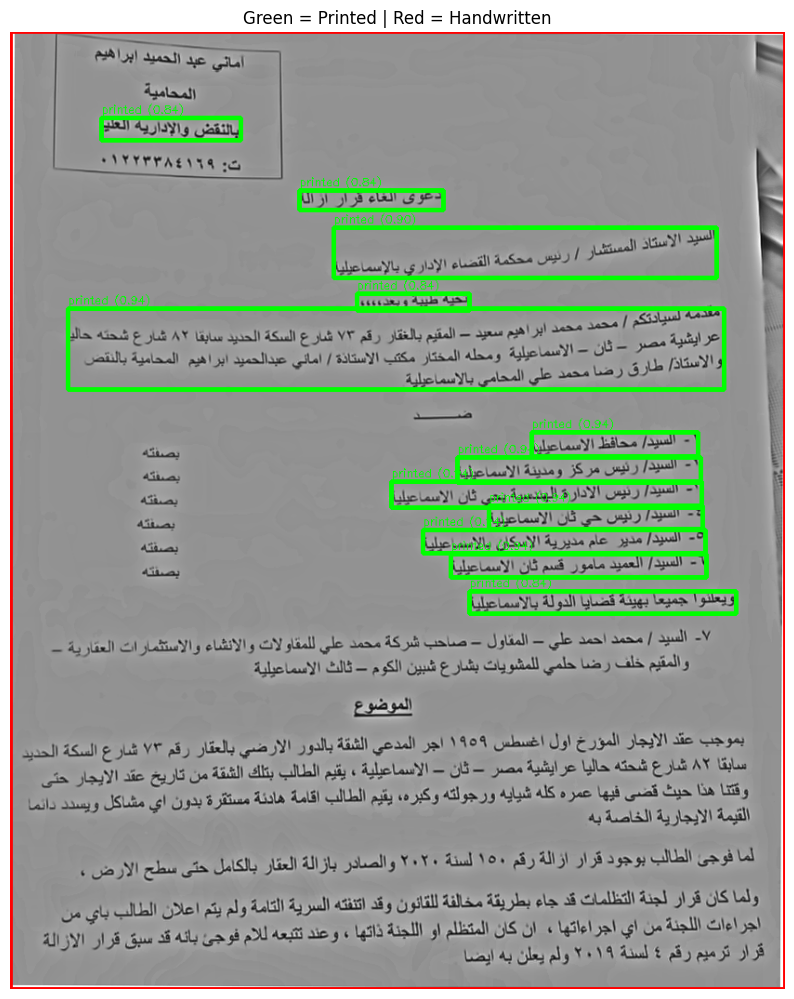

In [20]:
# Run layout analysis on the ISOLATED document (not the raw restored one)
structured_document = analyze_layout(isolated_document)

first_structured_page = structured_document.pages[0]

visualize_regions(
    isolated_document.pages[0].image,
    first_structured_page
)

## Layer 6: OCR Engine

**FIX**: The old OCR engine used `--psm 7` (single text line) for handwritten regions, but since almost everything was misclassified as handwritten, it was using single-line mode on multi-line blocks, producing terrible results.

Changes:
- Use `--psm 6` (uniform block of text) for printed regions -- this is the best mode for printed Arabic paragraphs
- Use `--psm 4` (single column, variable sizes) for handwritten, as it handles irregular layouts better
- Added Otsu binarization before OCR to improve text/background separation
- Filter out very low-confidence words from the output

In [21]:
# ==========================================
# OCR Output Dataclasses
# ==========================================

@dataclass
class OCRRegion:
    bbox: Tuple[int, int, int, int]
    region_type: str
    layout_confidence: float
    ocr_text: str
    ocr_confidence: float
    word_level_data: Optional[List[dict]]
    raw_engine_output: Optional[dict]


@dataclass
class OCRPage:
    page_number: int
    regions: List[OCRRegion]


@dataclass
class OCRDocument:
    pages: List[OCRPage]

In [22]:
# ==========================================
# Region-Aware OCR Engine (IMPROVED)
# ==========================================

class RegionAwareOCR:

    def __init__(self):
        # PSM 6 = Assume a single uniform block of text -- best for printed paragraphs
        # PSM 4 = Assume a single column of text of variable sizes -- better for handwritten
        # OEM 1 = LSTM neural network engine
        self.printed_config = "--oem 1 --psm 6 -l ara"
        self.handwritten_config = "--oem 1 --psm 4 -l ara"

    def _preprocess_for_ocr(self, image_rgb: np.ndarray, region_type: str) -> np.ndarray:
        """
        Preprocess a region image specifically for OCR.
        For printed text: sharpen + Otsu binarization for clean black/white.
        For handwritten: lighter preprocessing to preserve strokes.
        """
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

        if region_type == "printed":
            # Sharpen the image slightly
            sharpen_kernel = np.array([[-1, -1, -1],
                                       [-1,  9, -1],
                                       [-1, -1, -1]])
            gray = cv2.filter2D(gray, -1, sharpen_kernel)

            # Otsu binarization for clean text separation
            _, gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        else:
            # For handwritten: adaptive threshold is gentler
            gray = cv2.adaptiveThreshold(
                gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY, 21, 10
            )

        return gray

    def _ocr_printed(self, image_rgb):
        gray = self._preprocess_for_ocr(image_rgb, "printed")
        data = pytesseract.image_to_data(
            gray, config=self.printed_config,
            output_type=pytesseract.Output.DICT
        )
        # Filter words: only keep words with confidence > 0
        words = []
        for i, w in enumerate(data["text"]):
            if w.strip() != "":
                try:
                    conf = float(data["conf"][i])
                except (ValueError, TypeError):
                    conf = 0
                if conf > 10:  # Skip very low confidence garbage
                    words.append(w)
        text = " ".join(words)
        return text, data

    def _ocr_handwritten(self, image_rgb):
        gray = self._preprocess_for_ocr(image_rgb, "handwritten")
        data = pytesseract.image_to_data(
            gray, config=self.handwritten_config,
            output_type=pytesseract.Output.DICT
        )
        words = []
        for i, w in enumerate(data["text"]):
            if w.strip() != "":
                try:
                    conf = float(data["conf"][i])
                except (ValueError, TypeError):
                    conf = 0
                if conf > 5:
                    words.append(w)
        text = " ".join(words)
        return text, data

    def _postprocess_text(self, text: str):
        text = re.sub(r"\s+", " ", text)
        text = text.strip()
        return text

    def _arabic_ratio(self, text: str):
        arabic_chars = re.findall(r"[\u0600-\u06FF]", text)
        if len(text) == 0:
            return 0
        return len(arabic_chars) / len(text)

    def _compute_region_confidence(self, text, word_data):
        confidences = []
        for conf in word_data["conf"]:
            try:
                conf = float(conf)
                if conf > 0:
                    confidences.append(conf)
            except:
                continue

        if not confidences:
            base_conf = 0.0
        else:
            base_conf = sum(confidences) / len(confidences)

        # Penalize short output
        if len(text) < 3:
            base_conf *= 0.5

        # Penalize low Arabic ratio
        if self._arabic_ratio(text) < 0.4:
            base_conf *= 0.6

        # Penalize symbol-heavy text
        symbol_ratio = len(re.findall(r"[^\w\s\u0600-\u06FF]", text)) / (len(text) + 1e-5)
        if symbol_ratio > 0.3:
            base_conf *= 0.6

        return min(base_conf / 100.0, 1.0)

    def process_region(self, region):
        if region.region_type == "printed":
            text, raw_data = self._ocr_printed(region.cropped_image)
        else:
            text, raw_data = self._ocr_handwritten(region.cropped_image)

        text = self._postprocess_text(text)
        confidence = self._compute_region_confidence(text, raw_data)

        return OCRRegion(
            bbox=region.bbox,
            region_type=region.region_type,
            layout_confidence=region.confidence,
            ocr_text=text,
            ocr_confidence=float(confidence),
            word_level_data=raw_data,
            raw_engine_output=raw_data
        )

In [23]:
# ==========================================
# Run OCR on StructuredDocument
# ==========================================

def run_ocr(structured_document):
    print("\n[INFO] Starting Region-Aware OCR...\n")
    ocr_engine = RegionAwareOCR()
    ocr_pages = []

    for page in structured_document.pages:
        print(f"[PAGE {page.page_number}]")
        ocr_regions = []

        for idx, region in enumerate(page.regions):
            print(f"   -> Processing region {idx+1} ({region.region_type})")
            ocr_region = ocr_engine.process_region(region)
            print(f"      OCR Confidence: {ocr_region.ocr_confidence:.2f} | Text length: {len(ocr_region.ocr_text)}")
            ocr_regions.append(ocr_region)

        ocr_pages.append(
            OCRPage(page_number=page.page_number, regions=ocr_regions)
        )

    print("\n[SUCCESS] OCR completed.\n")
    return OCRDocument(pages=ocr_pages)

In [24]:
ocr_document = run_ocr(structured_document)

# Print results summary
for page in ocr_document.pages:
    for region in page.regions:
        if region.ocr_confidence < 0.4:
            print(f"\n[WARN] Low Confidence Region (Page {page.page_number})")
            print("Type:", region.region_type)
            print("Text:", region.ocr_text[:80])
            print("Confidence:", region.ocr_confidence)


[INFO] Starting Region-Aware OCR...

[PAGE 1]
   -> Processing region 1 (handwritten)
      OCR Confidence: 0.79 | Text length: 1572
   -> Processing region 2 (printed)
      OCR Confidence: 0.64 | Text length: 24
   -> Processing region 3 (printed)
      OCR Confidence: 0.50 | Text length: 33
   -> Processing region 4 (printed)
      OCR Confidence: 0.76 | Text length: 11
   -> Processing region 5 (printed)
      OCR Confidence: 0.75 | Text length: 9
   -> Processing region 6 (printed)
      OCR Confidence: 0.69 | Text length: 230
   -> Processing region 7 (printed)
      OCR Confidence: 0.44 | Text length: 16
   -> Processing region 8 (printed)
      OCR Confidence: 0.57 | Text length: 26
   -> Processing region 9 (printed)
      OCR Confidence: 0.75 | Text length: 33
   -> Processing region 10 (printed)
      OCR Confidence: 0.61 | Text length: 51
   -> Processing region 11 (printed)
      OCR Confidence: 0.71 | Text length: 41
   -> Processing region 12 (printed)
      OCR Confide

## Layer 7: Text Reconstruction

In [25]:
# ==========================================
# Reconstructed Document Dataclasses
# ==========================================

@dataclass
class CleanRegion:
    bbox: Tuple[int, int, int, int]
    region_type: str
    cleaned_text: str
    original_text: str
    final_confidence: float

@dataclass
class ReconstructedPage:
    page_number: int
    reconstructed_text: str
    regions: List[CleanRegion]

@dataclass
class ReconstructedDocument:
    pages: List[ReconstructedPage]
    full_text: str
    metadata: dict

In [26]:
# ==========================================
# Normalization & Cleaning Utilities
# ==========================================

def normalize_arabic(text: str) -> str:
    # Normalize Alef variants
    text = re.sub(r'[\u0625\u0623\u0622]', '\u0627', text)  # Alef variants -> Alef
    # Normalize Ya
    text = re.sub(r'\u0649', '\u064A', text)  # Alef Maksura -> Ya
    # Note: We do NOT normalize Ta Marbuta to Ha -- they are semantically different
    # in legal text (e.g. muhakama vs muhakamah)
    return text

def remove_duplicate_chars(text: str) -> str:
    return re.sub(r'(.)\1{2,}', r'\1', text)

def clean_text(text: str) -> str:
    text = text.strip()
    text = normalize_arabic(text)
    text = remove_duplicate_chars(text)
    text = re.sub(r'[\s]{2,}', ' ', text)
    # Keep Arabic chars, digits, whitespace, and common Arabic punctuation
    text = re.sub(r'[^\w\s\u0600-\u06FF\u0660-\u0669.,:;\u061B\u061F\-()\[\]/]', '', text)
    return text

In [27]:
# ==========================================
# TextReconstructor
# ==========================================

class TextReconstructor:

    def __init__(self, min_confidence_to_include: float = 0.1):
        """
        Args:
            min_confidence_to_include: Regions with final confidence below this
                                       threshold are dropped entirely (likely noise)
        """
        self.min_confidence_to_include = min_confidence_to_include

    def _clean_text(self, text: str) -> str:
        return clean_text(text)

    def _refine_confidence(self, layout_conf: float, ocr_conf: float, text: str) -> float:
        conf = layout_conf * 0.4 + ocr_conf * 0.6
        if len(text) < 3:
            conf *= 0.5
        symbol_ratio = len(re.findall(r'[^\w\s\u0600-\u06FF]', text)) / (len(text) + 1e-5)
        if symbol_ratio > 0.3:
            conf *= 0.6
        return min(conf, 1.0)

    def _merge_regions(self, regions: List[CleanRegion]) -> List[CleanRegion]:
        """Merge adjacent regions of the same type into paragraphs."""
        merged = []
        buffer = []
        current_type = None

        for region in regions:
            if region.region_type == current_type:
                buffer.append(region)
            else:
                if buffer:
                    merged.append(self._flush_buffer(buffer, current_type))
                buffer = [region]
                current_type = region.region_type

        if buffer:
            merged.append(self._flush_buffer(buffer, current_type))

        return merged

    def _flush_buffer(self, buffer: List[CleanRegion], region_type: str) -> CleanRegion:
        if len(buffer) == 1:
            return buffer[0]
        merged_text = "\n".join([r.cleaned_text for r in buffer if r.cleaned_text])
        merged_conf = sum([r.final_confidence for r in buffer]) / len(buffer)
        return CleanRegion(
            bbox=buffer[0].bbox,
            region_type=region_type,
            cleaned_text=merged_text,
            original_text="; ".join([r.original_text for r in buffer]),
            final_confidence=merged_conf
        )

    def _reconstruct_page(self, page) -> ReconstructedPage:
        clean_regions = []

        for region in page.regions:
            cleaned = self._clean_text(region.ocr_text)
            final_conf = self._refine_confidence(
                region.layout_confidence, region.ocr_confidence, cleaned
            )

            # Skip empty or very low confidence regions (noise)
            if not cleaned.strip() and final_conf < self.min_confidence_to_include:
                continue

            clean_regions.append(CleanRegion(
                bbox=region.bbox,
                region_type=region.region_type,
                cleaned_text=cleaned,
                original_text=region.ocr_text,
                final_confidence=final_conf
            ))

        merged_regions = self._merge_regions(clean_regions)

        # Build page text without type markers (cleaner for LLM)
        page_text = "\n".join(
            region.cleaned_text for region in merged_regions if region.cleaned_text.strip()
        )

        return ReconstructedPage(
            page_number=page.page_number,
            reconstructed_text=page_text.strip(),
            regions=merged_regions
        )

    def _build_full_text(self, pages: List[ReconstructedPage]) -> str:
        full_text = ""
        for page in pages:
            if len(pages) > 1:
                full_text += f"-------- PAGE {page.page_number} --------\n"
            full_text += page.reconstructed_text + "\n\n"
        return full_text.strip()

    def reconstruct_document(self, ocr_document) -> ReconstructedDocument:
        reconstructed_pages = []

        for page in ocr_document.pages:
            reconstructed_pages.append(self._reconstruct_page(page))

        full_text = self._build_full_text(reconstructed_pages)

        num_handwritten = sum(
            len([r for r in page.regions if r.region_type == "handwritten"])
            for page in reconstructed_pages
        )
        num_printed = sum(
            len([r for r in page.regions if r.region_type == "printed"])
            for page in reconstructed_pages
        )
        total_regions = sum(len(page.regions) for page in reconstructed_pages)

        avg_conf = sum(
            r.final_confidence
            for page in reconstructed_pages
            for r in page.regions
        ) / max(1, total_regions)

        metadata = {
            "pages_count": len(reconstructed_pages),
            "handwritten_regions": num_handwritten,
            "printed_regions": num_printed,
            "avg_confidence": avg_conf
        }

        return ReconstructedDocument(
            pages=reconstructed_pages,
            full_text=full_text,
            metadata=metadata
        )

In [28]:
reconstructor = TextReconstructor()
reconstructed_doc = reconstructor.reconstruct_document(ocr_document)

print("=" * 60)
print("RECONSTRUCTED TEXT (before LLM refinement)")
print("=" * 60)
print(reconstructed_doc.full_text)

print("\nMetadata:", reconstructed_doc.metadata)

RECONSTRUCTED TEXT (before LLM refinement)
المحامية بالنقض والادارية العليا ادعوي الغاء قرار ازالة السيد الاستاذ الي ب استاذ المستشار اريس مقدمه محمد محمد ا شم بالفق 8 قا 4 شارء شحت عرايشية عن شي نادم سعيد د المقم بالغقار رقم 5 شارع السكة الحديد سابقا 4 شارع شحته حاليا محكمة التضياء الاداري بالاسماعيلية والاستلا/ طارق رضا محمد المخار مكتب الاستاذة / اماني عبدالحميد ابراهيم المحامية بالنقص ضهة -١ السيدم محافظ الاسماعيلية 8 - السيد/ رئيس مركز ومدينة الاسماعيلية 8 - السيد/ رئيس الادارة الهندسية بحي ثان الاسماعيلية بصت 4- السيد/ رئيس حي ثان الاسماعيلية - السيدم مدير عام مديرية الاسكان بالاسماعيلية بصفت 1- السيد/ العميد مامور قسم ثان الاسماعيلية 97 ويعلنوا جميعا بهيئة قضايا الدولة بالاسماعيلية السيد 5 اك 8 5 بيد / محمد احمد علي - المقاول - صاحب شركة محمد علي للمقاولات والانشاء والاستثمارات العقا ية- والمقيم خلف رضا حلمي للمشويات بشارع شبين الكوم - ثالث الاسماعيلية 1 الموضوع يموجب عتد الايجار المؤرخ اول اغسطس اجر المدعي الشقة بالدور الارضي بالعتار رقم ؟ شارع السكة الحديد سابقا 85 شارع شحته ح

## Layer 8: LLM Refinement

This layer sends the raw OCR output to an LLM to:
1. Correct OCR errors (misread Arabic characters, broken words)
2. Fix grammatical issues introduced by OCR
3. Reconstruct proper Arabic sentence structure
4. Preserve legal terminology accurately

The LLM acts as a post-processing correction layer, not a content generator.
It is instructed to only fix obvious OCR errors without changing meaning.

In [29]:
# ==========================================
# LLM Refinement Dataclasses
# ==========================================

@dataclass
class RefinedPage:
    page_number: int
    original_text: str
    refined_text: str

@dataclass
class RefinedDocument:
    pages: List[RefinedPage]
    full_refined_text: str
    metadata: dict

In [30]:
# ==========================================
# LLM-based OCR Refinement
# ==========================================

class LLMOCRRefiner:
    """
    Uses an LLM to correct OCR errors in Arabic legal text.

    Supports multiple backends:
    - OpenAI (GPT-4o, GPT-4o-mini)
    - Google (Gemini)
    - Local/custom endpoints

    The refiner sends the raw OCR text with a carefully crafted system
    prompt that instructs the LLM to:
    - Fix OCR character-level errors
    - NOT change the meaning or add content
    - Preserve legal terminology
    - Fix Arabic text direction issues
    """

    SYSTEM_PROMPT = """أنت نظام متخصص في تصحيح أخطاء التعرف الضوئي على الحروف (OCR) في المستندات القضائية العربية، وخاصة المستندات القانونية المصرية مثل:

    - الأحكام القضائية
    - مذكرات الدفاع
    - صحف الدعاوى
    - محاضر الجلسات
    - تقارير الخبراء
    - المستندات المقدمة للمحكمة
    
    مهمتك هي **تصحيح النص الناتج عن OCR فقط** مع الحفاظ الكامل على المعنى القانوني الأصلي للنص.
    
    --------------------------------------------------
    قواعد التصحيح
    --------------------------------------------------
    
    1. قم بتصحيح أخطاء OCR الواضحة فقط مثل:
       - الحروف العربية الملتبسة (ب / ت / ث / ن / ي)
       - الخلط بين (ا / ل / د / ذ / ر / ز)
       - الكلمات المكسورة أو المقطوعة بسبب OCR
       - الكلمات المدموجة خطأ
       - الحروف المكررة أو الرموز غير المفهومة
    
    2. قم بإعادة تكوين الكلمات القانونية التي تم تشويهها بسبب OCR.
    
    3. حافظ على **جميع المصطلحات القانونية كما هي** مثل:
       - المدعي
       - المدعى عليه
       - المحكمة
       - الدائرة
       - حيثيات الحكم
       - وقائع الدعوى
       - الطلبات
       - الأسباب
       - الحكم
       - المرافعة
       - محضر الجلسة
       - خبير الدعوى
    
    4. لا تقم **بإضافة أي معلومات جديدة أو تفسير قانوني**.
    
    5. لا تقم **بحذف أي جزء من النص** إلا إذا كان:
       - رموز عشوائية
       - تكرار غير منطقي للحروف
       - ضوضاء OCR واضحة
    
    6. حافظ على **بنية الفقرات الأصلية** كما هي.
    
    7. إذا كانت الكلمة غير واضحة تماماً:
       - اختر التفسير الأكثر منطقية **في السياق القانوني**.
    
    8. قم بتصحيح علامات الترقيم العربية إذا كانت واضحة الخطأ:
       - الفاصلة
       - النقطة
       - الأقواس
       - النقطتان
    
    9. لا تقم بتغيير:
       - أرقام القضايا
       - التواريخ
       - أرقام المواد القانونية
       - أسماء الأشخاص
       - أسماء الجهات
    
    10. يجب أن يكون النص النهائي **صياغة قانونية عربية سليمة** كما تظهر في المستندات القضائية الرسمية.
    
    --------------------------------------------------
    صيغة الإخراج
    --------------------------------------------------
    
    أخرج **النص المصحح فقط**.
    
    لا تضف:
    - شروحات
    - تعليقات
    - علامات
    - تنسيق إضافي
    - عناوين
    
    إذا كان النص صحيحاً بالفعل، قم بإرجاعه كما هو بدون تغيير.
    
    --------------------------------------------------
    النص المراد تصحيحه
    --------------------------------------------------
    
    {ocr_text}"""

    def __init__(self, provider: str = "google", model: str = "gemini-2.5-flash", api_key: Optional[str] = None):
        """
        Args:
            provider: "openai" or "google"
            model: Model name (e.g. "gpt-4o-mini", "gemini-1.5-flash")
            api_key: API key. If None, reads from environment variable.
        """
        self.provider = provider
        self.model = model
        self.api_key = api_key
        self._client = None

    def _get_client(self):
        if self._client is not None:
            return self._client

        if self.provider == "google":
            key = self.api_key or os.environ.get("GOOGLE_API_KEY")
            if not key:
                raise ValueError("GOOGLE_API_KEY not set")
            genai.configure(api_key=key)
            self._client = genai.GenerativeModel(self.model)

        else:
            raise ValueError(f"Unsupported provider: {self.provider}")

        return self._client

    def _call_llm(self, text: str) -> str:
        """Send text to the LLM and get corrected output."""
        client = self._get_client()

        if self.provider == "google":
            prompt = f"{self.SYSTEM_PROMPT}\n\n---\n\n{text}"
            response = client.generate_content(
                prompt,
                generation_config={"temperature": 0.1, "max_output_tokens": 4096}
            )
            return response.text.strip()

    def refine_page(self, page_text: str) -> str:
        """
        Refine a single page of OCR text.
        Splits into chunks if text is too long for the model context.
        """
        if not page_text.strip():
            return page_text

        # For very long pages, split into chunks of ~2000 chars
        max_chunk_size = 2000
        if len(page_text) <= max_chunk_size:
            return self._call_llm(page_text)

        # Split by newlines to avoid breaking mid-sentence
        lines = page_text.split("\n")
        chunks = []
        current_chunk = ""

        for line in lines:
            if len(current_chunk) + len(line) + 1 > max_chunk_size:
                if current_chunk:
                    chunks.append(current_chunk)
                current_chunk = line
            else:
                current_chunk += ("\n" if current_chunk else "") + line

        if current_chunk:
            chunks.append(current_chunk)

        refined_chunks = []
        for i, chunk in enumerate(chunks):
            print(f"      Refining chunk {i+1}/{len(chunks)}...")
            refined_chunks.append(self._call_llm(chunk))

        return "\n".join(refined_chunks)

    def refine_document(self, reconstructed_doc: ReconstructedDocument) -> RefinedDocument:
        """
        Refine the entire reconstructed document using LLM.
        """
        print("\n[INFO] Starting LLM OCR refinement...\n")

        refined_pages = []

        for page in reconstructed_doc.pages:
            print(f"[PAGE {page.page_number}]")
            print(f"   -> Original text length: {len(page.reconstructed_text)} chars")

            try:
                refined_text = self.refine_page(page.reconstructed_text)
                print(f"   -> Refined text length: {len(refined_text)} chars")
            except Exception as e:
                print(f"   [ERROR] LLM refinement failed: {e}")
                print(f"   -> Falling back to original text")
                refined_text = page.reconstructed_text

            refined_pages.append(RefinedPage(
                page_number=page.page_number,
                original_text=page.reconstructed_text,
                refined_text=refined_text
            ))

        # Build full refined text
        full_text_parts = []
        for p in refined_pages:
            if len(refined_pages) > 1:
                full_text_parts.append(f"-------- PAGE {p.page_number} --------")
            full_text_parts.append(p.refined_text)

        full_refined_text = "\n\n".join(full_text_parts).strip()

        metadata = {
            **reconstructed_doc.metadata,
            "llm_provider": self.provider,
            "llm_model": self.model,
            "refinement_applied": True
        }

        print("\n[SUCCESS] LLM refinement complete.\n")

        return RefinedDocument(
            pages=refined_pages,
            full_refined_text=full_refined_text,
            metadata=metadata
        )

In [31]:
# ==========================================
# Run LLM Refinement
# ==========================================
#
# To use, set your API key:
#   For OpenAI: os.environ["OPENAI_API_KEY"] = "sk-..."
#   For Google: os.environ["GOOGLE_API_KEY"] = "..."
#
# Then choose your provider/model:
#   refiner = LLMOCRRefiner(provider="openai", model="gpt-4o-mini")
#   

try:
    refiner = LLMOCRRefiner()
    refined_doc = refiner.refine_document(reconstructed_doc)

    print("=" * 60)
    print("FINAL REFINED TEXT")
    print("=" * 60)
    print(refined_doc.full_refined_text)
    print("\nMetadata:", refined_doc.metadata)

except Exception as e:
    print(f"[WARN] LLM refinement skipped: {e}")
    print("Set your API key to enable LLM refinement.")
    print("\nFalling back to unrefineed OCR output:")
    print(reconstructed_doc.full_text)


[INFO] Starting LLM OCR refinement...

[PAGE 1]
   -> Original text length: 2120 chars
      Refining chunk 1/2...
      Refining chunk 2/2...
   -> Refined text length: 561 chars

[SUCCESS] LLM refinement complete.

FINAL REFINED TEXT
المحامية بالنقض والإدارية العليا
    دعوى إلغاء قرار إزالة

    مقدمة من السيد/ محمد محمد إبراهيم سعيد - المقيم بالعقار رقم 4 شارع السكة الحديد سابقاً، 4 شارع شحتة حالياً، عرايشية مصر - ثان - الإسماعيلية.
    ومحله المختار مكتب الأستاذة/ أماني عبدالحميد إبراهيم المحامية بالنقض، والأستاذ/ طارق رضا محمد علي المحامي بالإسماعيلية.

    ضد:
    1- السيد/ محافظ الإسماعيلية بصفته.
    2- السيد/ رئيس مركز ومدينة الإسماعيلية بصفته.
- السيد/ العميد مأمور قسم ثان الإسماعيلية
- السيد/ مدير عام مديرية الإسكان بالإسماعيلية
ويعنون جميعاً بهيئة قضايا الدولة بالإسماعيلية.

Metadata: {'pages_count': 1, 'handwritten_regions': 1, 'printed_regions': 1, 'avg_confidence': 0.7206034609720178, 'llm_provider': 'google', 'llm_model': 'gemini-2.5-flash', 'refinement_applied': True

In [32]:
# ==========================================
# Side-by-side comparison (if LLM refinement was successful)
# ==========================================

try:
    if refined_doc:
        for page in refined_doc.pages:
            print(f"\n{'='*60}")
            print(f"PAGE {page.page_number} - BEFORE LLM:")
            print(f"{'='*60}")
            print(page.original_text[:500])
            print(f"\n{'='*60}")
            print(f"PAGE {page.page_number} - AFTER LLM:")
            print(f"{'='*60}")
            print(page.refined_text[:500])
except NameError:
    print("LLM refinement was not run. Set API key and re-run the previous cell.")


PAGE 1 - BEFORE LLM:
المحامية بالنقض والادارية العليا ادعوي الغاء قرار ازالة السيد الاستاذ الي ب استاذ المستشار اريس مقدمه محمد محمد ا شم بالفق 8 قا 4 شارء شحت عرايشية عن شي نادم سعيد د المقم بالغقار رقم 5 شارع السكة الحديد سابقا 4 شارع شحته حاليا محكمة التضياء الاداري بالاسماعيلية والاستلا/ طارق رضا محمد المخار مكتب الاستاذة / اماني عبدالحميد ابراهيم المحامية بالنقص ضهة -١ السيدم محافظ الاسماعيلية 8 - السيد/ رئيس مركز ومدينة الاسماعيلية 8 - السيد/ رئيس الادارة الهندسية بحي ثان الاسماعيلية بصت 4- السيد/ رئيس حي ثان 

PAGE 1 - AFTER LLM:
المحامية بالنقض والإدارية العليا
    دعوى إلغاء قرار إزالة

    مقدمة من السيد/ محمد محمد إبراهيم سعيد - المقيم بالعقار رقم 4 شارع السكة الحديد سابقاً، 4 شارع شحتة حالياً، عرايشية مصر - ثان - الإسماعيلية.
    ومحله المختار مكتب الأستاذة/ أماني عبدالحميد إبراهيم المحامية بالنقض، والأستاذ/ طارق رضا محمد علي المحامي بالإسماعيلية.

    ضد:
    1- السيد/ محافظ الإسماعيلية بصفته.
    2- السيد/ رئيس مركز ومدينة الإسماعيلية بصفته.
- السيد/ العميد مأمور قسم ثان

## Summary of Changes

### 1. Page Isolation (NEW - Layer 4)
- Added `PageIsolator` class that detects the physical page boundary using Canny edges + contour detection
- Masks everything outside the page to white, preventing OCR from picking up scanner artifacts
- Crops to the page bounding box with a configurable margin

### 2. Image Restoration (IMPROVED - Layer 2)
- Removed `_repair_strokes` (morphological closing) which was destroying Arabic diacritics on printed text
- Kept denoise + contrast enhancement + background normalization

### 3. Deskewing (NEW - Layer 3)
- Added `DocumentDeskewer` class that detects and corrects document tilt/rotation
- Uses two complementary methods: Hough Line Transform and minimum-area-rectangle fitting
- Combines both estimates for robust angle detection
- Handles photographed documents where the paper may be rotated or text lines tilted
- Configurable max skew angle and tolerance to avoid false corrections
- Expands canvas during rotation to prevent corner cropping

### 4. Layout Analysis (IMPROVED - Layer 5)
- Raised classification thresholds significantly for Arabic text characteristics
- Added `line_spacing_regularity` feature (printed text has uniform line spacing)
- Changed default assumption to "printed" instead of "handwritten"
- Requires stronger evidence (score >= 3.0 vs old 2.0) before labeling as handwritten
- Better noise filtering: edge margins, aspect ratio checks, morphological opening to remove specks

### 5. OCR Engine (IMPROVED - Layer 6)
- Changed printed config to PSM 6 (uniform text block) -- best for paragraphs
- Changed handwritten config to PSM 4 (variable column) -- better than PSM 7 for multi-line
- Added `_preprocess_for_ocr` with Otsu binarization for printed and adaptive threshold for handwritten
- Added confidence-based word filtering to remove OCR garbage

### 6. Text Reconstruction (IMPROVED - Layer 7)
- Removed `[HANDWRITTEN]`/`[PRINTED]` markers from output text (cleaner for LLM)
- Fixed Ta Marbuta normalization (should NOT normalize in legal text)
- Skip empty/low-confidence noise regions entirely
- Improved region merging to merge any adjacent same-type regions

### 7. LLM Refinement (NEW - Layer 8)
- Added `LLMOCRRefiner` class supporting OpenAI and Google Gemini
- Specialized system prompt for Arabic legal OCR correction
- Chunk-based processing for long documents
- Graceful fallback if API key is not set